# 4. Performance Tracking (Multi-Tenor, Live)

Live forward P&L for the ISA, reported side-by-side across three tenors:

- **Overall** — since the first trade on **12-May-2025**.
- **FY25** — 05-Apr-2025 → 04-Apr-2026 (UK financial year 2025-26).
- **FY26** — 05-Apr-2026 → today (UK financial year 2026-27, in-flight).

Unlike the FY25 backtest in [`05_backtesting.ipynb`](05_backtesting.ipynb), this notebook is designed to re-run regularly: it picks up new trades from the combined 2025 + 2026 InvestEngine statements (parsed and persisted to the SQLite DB) and extends the rolling P&L through today.

**Cash deposits:** FY25 £20,000 (all IE) · FY26 £10,000 (£8,200 IE + £1,800 Trading212 on 13-Apr-2026 for WSIL/AIGA/AIGE/COPA) · Total £30,000. The £1,800 Trading212 portion is **excluded** from TWR / MWR / Sharpe figures because Trading212 trade statements are not available — but those four tickers are surfaced in the final holdings snapshot as estimated positions (£450 each at 13-Apr-2026 close).

### Section map

1. **Trade ledger** — combine IE 2025 + 2026 statements into one ledger.
2. **Headline summary** — TWR / MWR / annualised vol / Sharpe, one row per tenor.
3. **Daily TWR curve** — rebased to 0% at each tenor start so the three lines are directly comparable.
4. **Rolling 30-day volatility** — regime shifts over each tenor.
5. **Holdings snapshot** — share ledger valued at FY25 close and today (with T212 positions).
6. **Pro metrics vs blended benchmark** — annualised ret/vol, Sharpe, beta, TE, information ratio.
7. **Appendix — data quality & coverage check** — price-history coverage for every ticker from FY25 start to today.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from etf_utils.config import RISK_FREE_RATE, PROJECT_ROOT
from etf_utils.data_provider import DataProvider
from etf_utils.database import (
    load_portfolio,
    save_rebalancing_trades,
)
from etf_utils.backtesting import (
    Backtester,
    combine_investengine_statements,
    rebase_cumret,
)
from etf_utils.metrics import (
    calculate_beta,
    calculate_information_ratio,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_tracking_error,
    rolling_volatility_from_cumret,
)

FIRST_TRADE_DATE = pd.Timestamp("2025-05-12")
FY25_START, FY25_END = pd.Timestamp("2025-04-05"), pd.Timestamp("2026-04-04")
FY26_START = pd.Timestamp("2026-04-05")
TODAY      = pd.Timestamp.now().normalize()

TENORS = {
    "Overall": (FIRST_TRADE_DATE, TODAY),
    "FY25":    (FY25_START, FY25_END),
    "FY26":    (FY26_START, TODAY),
}
TENOR_COLOURS = {"Overall": "#0f172a", "FY25": "#3b82f6", "FY26": "#10b981"}

DEPOSITS_IE = {"Overall": 28_200.0, "FY25": 20_000.0, "FY26": 8_200.0}

# Trading212 portion of the FY26 deposit — not in any IE statement, so treat as
# a synthetic equal-split buy at the 13-Apr-2026 close. Used only in the final
# holdings snapshot; excluded from all TWR / MWR / Sharpe metrics.
T212_DEPOSIT_DATE = pd.Timestamp("2026-04-13")
T212_TICKERS = ["WSIL", "AIGA", "AIGE", "COPA"]
T212_DEPOSIT_EACH = 450.0  # £1,800 / 4

provider = DataProvider()
portfolio_26 = load_portfolio(year=2026)
portfolio_25 = load_portfolio(year=2025)
print(f"Loaded 2026 portfolio: {len(portfolio_26)} positions, "
      f"{portfolio_26['asset_class'].nunique()} asset classes.")
print(f"Loaded 2025 portfolio: {len(portfolio_25)} positions "
      f"(used for FY25 benchmark).")
for name, (s, e) in TENORS.items():
    print(f"  {name:8s}  {s.date()} → {e.date()}   deposits = £{DEPOSITS_IE[name]:,.0f}")

Loaded 2026 portfolio: 20 positions, 4 asset classes.
Loaded 2025 portfolio: 16 positions (used for FY25 benchmark).
  Overall   2025-05-12 → 2026-04-19   deposits = £28,200
  FY25      2025-04-05 → 2026-04-04   deposits = £20,000
  FY26      2026-04-05 → 2026-04-19   deposits = £8,200


## 1. Trade Ledger — InvestEngine Statements

Parses `RebalancingTrades2025.csv` and `RebalancingTrades2026.csv`, deduplicates on `(trade_datetime, ticker, type, quantity)`, and persists the combined ledger to the DB under `portfolio_year=2026` (the continuing ISA). Every downstream metric is derived from this ledger. Trading212 trades are **not** included — the T212 export is unavailable.

In [2]:
stmt_dir = PROJECT_ROOT / "data" / "investment_statements"
trades = combine_investengine_statements(
    stmt_dir / "RebalancingTrades2025.csv",
    stmt_dir / "RebalancingTrades2026.csv",
)
save_rebalancing_trades(trades, portfolio_year=2026)

print(f"Parsed {len(trades)} combined trades and saved to DB.")
print(f"Date range: {trades['trade_date'].min().date()} \u2192 "
      f"{trades['trade_date'].max().date()}")
print(f"Tickers: {trades['ticker'].nunique()}")


Parsed 399 combined trades and saved to DB.
Date range: 2025-05-12 → 2026-04-14
Tickers: 22


## 2. Headline Summary — TWR / MWR / Vol / Sharpe by Tenor

Top-line numbers, one row per tenor.

- **TWR** — rebased cumulative time-weighted return (price return of the IE-tracked portfolio, chained across rebalances).
- **MWR** — `ending_value / cash_deposited - 1`; answers "what is my investment actually worth vs cash in?".
- **Ann. Vol** — annualised daily-return volatility of the rebased TWR (always ≥ 0).
- **Sharpe** — annualised excess return over `RISK_FREE_RATE` divided by annualised vol.

Negative TWR / MWR / Sharpe show in red. `ending_value` marks the IE share ledger to market at the tenor's end date; `cash_deposited` is IE-only (the £1,800 Trading212 deposit is excluded from both sides of the ratio so the MWR is self-consistent).

In [3]:
# Backtester and master TWR series are built here because the summary is the
# first narrative section; the later curve / vol / pro-metrics cells reuse
# these variables without rebuilding.
bt = Backtester.from_trades(trades, provider, end_date=TODAY)
master_twr = bt.run_twr_series(trades)

rows = []
for name, (s, e) in TENORS.items():
    ledger = trades[trades["trade_date"] <= e].groupby("ticker")["signed_qty"].sum()
    end_val = 0.0
    for t, sh in ledger.items():
        if sh <= 0:
            continue
        px = bt.get_price(t, e)
        if px:
            end_val += sh * px
    cash = DEPOSITS_IE[name]
    twr_series_tenor = rebase_cumret(master_twr.loc[:e], s)
    twr = twr_series_tenor.iloc[-1] if not twr_series_tenor.empty else float("nan")
    mwr = (end_val / cash - 1) * 100 if cash > 0 else float("nan")

    if len(twr_series_tenor) >= 5:
        daily_ret = (1 + twr_series_tenor / 100).pct_change().dropna()
        ann_vol = float(daily_ret.std() * np.sqrt(252) * 100)
        n_days = (twr_series_tenor.index[-1] - twr_series_tenor.index[0]).days
        ann_ret = ((1 + twr / 100) ** (365 / n_days) - 1) * 100 if n_days > 0 else float("nan")
        sharpe = calculate_sharpe_ratio(ann_ret, ann_vol)
    else:
        ann_vol = sharpe = float("nan")

    rows.append({
        "start": s.date(),
        "end": e.date(),
        "days": (e - s).days,
        "cash_deposited": cash,
        "ending_value": round(end_val, 2),
        "twr_pct": round(twr, 2),
        "mwr_pct": round(mwr, 2),
        "ann_vol_pct": round(ann_vol, 2),
        "sharpe": round(sharpe, 2),
    })

summary_df = pd.DataFrame(rows, index=list(TENORS))


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


styled = (summary_df.style
    .format({
        "cash_deposited": "£{:,.0f}",
        "ending_value": "£{:,.2f}",
        "twr_pct": "{:+.2f}%",
        "mwr_pct": "{:+.2f}%",
        "ann_vol_pct": "{:.2f}%",
        "sharpe": "{:+.2f}",
    })
    .map(_colour_neg, subset=["twr_pct", "mwr_pct", "sharpe"])
    .set_caption("TWR / MWR / Ann. Vol / Sharpe by Tenor "
                 "(IE-only; £1,800 Trading212 portion excluded)"))
display(styled)

C:\Users\rakes\My Drive\dev\etf-isa-portfolio\etf_utils\backtesting.py:253: UserWarning: Ticker 'RMAP' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data[ticker] = provider.get_historical_prices(ticker)


,start,end,days,cash_deposited,ending_value,twr_pct,mwr_pct,ann_vol_pct,sharpe
Overall,2025-05-12,2026-04-19,342,"£28,200","£32,446.30",+20.44%,+15.06%,9.71%,+2.27
FY25,2025-04-05,2026-04-04,364,"£20,000","£23,091.60",+15.62%,+15.46%,9.49%,+1.86
FY26,2026-04-05,2026-04-19,14,"£8,200","£32,446.30",+4.17%,+295.69%,14.21%,+20.24


## 3. Daily TWR Curve — Tenor Comparison

The master TWR series from section 2, sliced and rebased to 0% at the start of each tenor so the three lines are directly comparable. Each line answers: "how has £1 invested at the start of this period performed?" Thin vertical lines mark every rebalance date in the IE ledger.

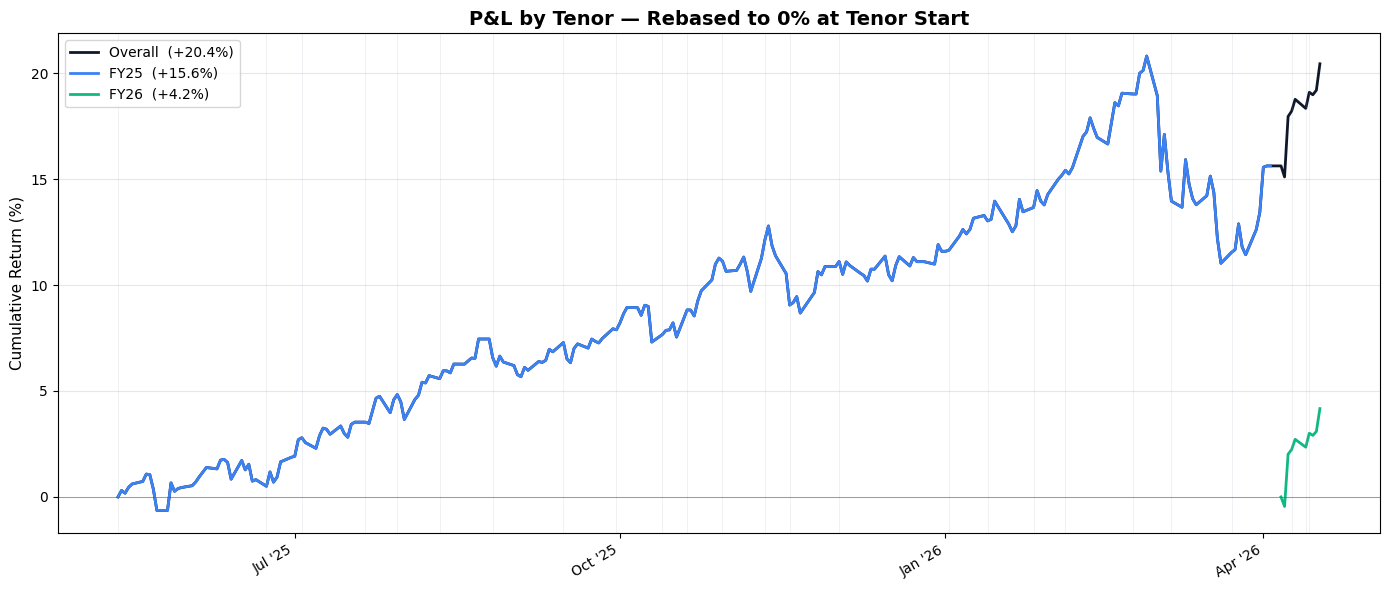

Tenor-final TWR (rebased):
  Overall    +20.44%
  FY25       +15.62%
  FY26        +4.17%


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if series.empty:
        continue
    ax.plot(series.index, series, color=TENOR_COLOURS[name],
            linewidth=2.0, label=f"{name}  ({series.iloc[-1]:+.1f}%)")

rb_dates = [d for d in sorted(pd.to_datetime(trades["trade_date"]).unique())
            if FIRST_TRADE_DATE <= pd.Timestamp(d) <= TODAY]
for rd in rb_dates:
    ax.axvline(rd, color="#94a3b8", alpha=0.15, linewidth=0.7)

ax.axhline(0, color="#475569", linewidth=0.6, alpha=0.6)
ax.set_title("P&L by Tenor — Rebased to 0% at Tenor Start",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

print("Tenor-final TWR (rebased):")
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if not series.empty:
        print(f"  {name:8s}  {series.iloc[-1]:+7.2f}%")

## 4. Rolling 30-Day Volatility — Tenor Comparison

Annualised 30-day rolling volatility computed on the *rebased* TWR slice for each tenor. FY25 and Overall lines show a ~3-week NaN warm-up at the start (the 30-day window needs to fill); that's expected. Any period where one tenor's vol rises visibly above the others signals a regime shift local to that window.

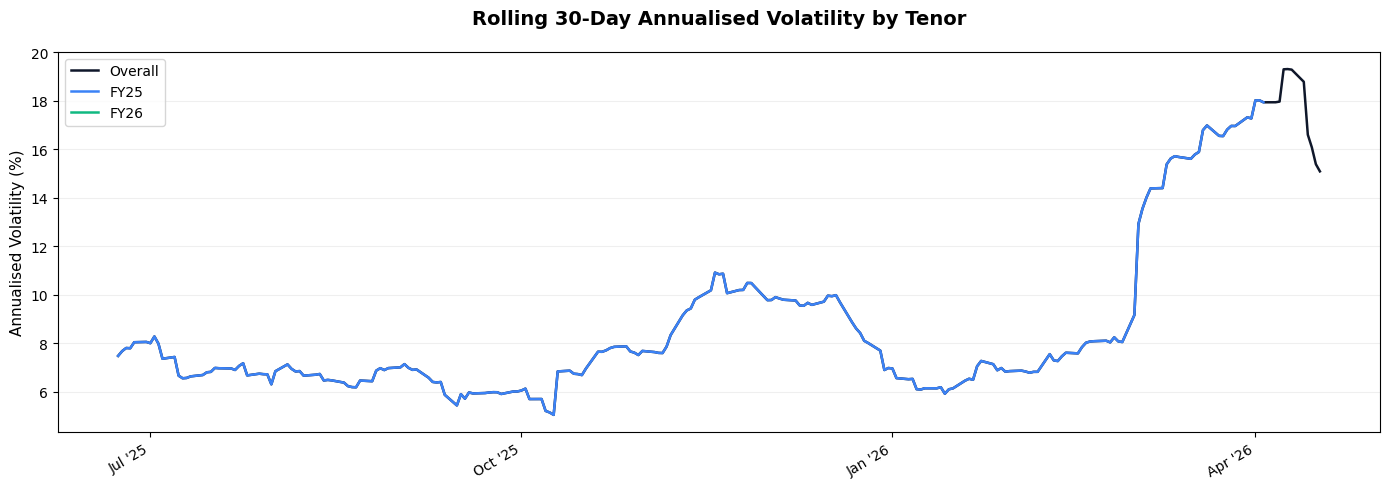

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if series.empty:
        continue
    vol = rolling_volatility_from_cumret(series, window=30)
    ax.plot(vol.index, vol, color=TENOR_COLOURS[name], linewidth=1.8, label=name)

ax.set_title("Rolling 30-Day Annualised Volatility by Tenor",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Annualised Volatility (%)", fontsize=11)
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


## 5. Holdings Snapshot

Two share-ledger snapshots, valued at each date's closing prices:

- **FY25 close (2026-04-04)** — IE-only positions; includes the 23-Mar-2026 pre-rebalance trades (by design, so the snapshot aligns with the FY25 tenor end).
- **Today** — current portfolio, including both IE positions and **estimated Trading212 positions** (WSIL / AIGA / AIGE / COPA) derived from the £450-per-ticker deposit on 13-Apr-2026. T212 rows are flagged in the `Platform` column; they carry no real trade confirmations, so treat the shares/value as approximate.

Red highlights mark negative `P&L (£)` or `MWR (%)` values. Footer totals sum IE + T212 so the "Today" total lines up with the £30,000 all-in capital deposited.

In [6]:
def _ie_holdings_at(trades_df, as_of):
    ledger = defaultdict(float)
    cost = defaultdict(float)
    for _, t in trades_df[trades_df["trade_date"] <= as_of].iterrows():
        ledger[t["ticker"]] += t["signed_qty"]
        cost[t["ticker"]] += t["signed_value"]
    rows = []
    for tk in sorted(ledger):
        shares = ledger[tk]
        if shares <= 0:
            continue
        px = bt.get_price(tk, as_of) or 0.0
        val = shares * px
        c = cost[tk]
        mwr = (val / c - 1) * 100 if c > 0 else 0.0
        rows.append({
            "Platform": "IE",
            "Ticker": tk,
            "Shares": round(shares, 4),
            "Price (£)": round(px, 2),
            "Value (£)": round(val, 2),
            "Cost (£)": round(c, 2),
            "P&L (£)": round(val - c, 2),
            "MWR (%)": round(mwr, 2),
        })
    return pd.DataFrame(rows)


def _t212_synthetic_today():
    """Estimate current T212 positions: £450 per ticker at 13-Apr-2026 close."""
    rows = []
    for tk in T212_TICKERS:
        try:
            close = provider.get_historical_prices(tk)["close"].dropna()
            buy_px = close.loc[:T212_DEPOSIT_DATE].iloc[-1]
            now_px = close.loc[:TODAY].iloc[-1]
        except Exception as exc:
            print(f"  T212 price fetch failed for {tk}: {exc}")
            continue
        shares = T212_DEPOSIT_EACH / buy_px
        val = shares * now_px
        cost = T212_DEPOSIT_EACH
        rows.append({
            "Platform": "T212*",
            "Ticker": tk,
            "Shares": round(shares, 4),
            "Price (£)": round(now_px, 2),
            "Value (£)": round(val, 2),
            "Cost (£)": round(cost, 2),
            "P&L (£)": round(val - cost, 2),
            "MWR (%)": round((val / cost - 1) * 100, 2),
        })
    return pd.DataFrame(rows)


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


for label, as_of in [("FY25 close", FY25_END), ("Today", TODAY)]:
    df = _ie_holdings_at(trades, as_of)
    if label == "Today":
        df = pd.concat([df, _t212_synthetic_today()], ignore_index=True)

    print(f"\n--- Holdings at {label} ({as_of.date()}) ---")
    styled = (df.style
        .format({
            "Shares":     "{:.4f}",
            "Price (£)": "£{:.2f}",
            "Value (£)": "£{:,.2f}",
            "Cost (£)":  "£{:,.2f}",
            "P&L (£)":   "{:+,.2f}",
            "MWR (%)":    "{:+.2f}%",
        })
        .map(_colour_neg, subset=["P&L (£)", "MWR (%)"])
        .hide(axis="index"))
    display(styled)
    t_val = df["Value (£)"].sum()
    t_cost = df["Cost (£)"].sum()
    t_pl = df["P&L (£)"].sum()
    print(f"  Total Value: £{t_val:,.2f}   "
          f"Total Cost: £{t_cost:,.2f}   "
          f"Total P&L: £{t_pl:,.2f}")
    if label == "Today":
        print("  T212* rows are estimated (£450 per ticker at 13-Apr-2026 close) "
              "— no trade confirmations available.")


--- Holdings at FY25 close (2026-04-04) ---


Platform,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
IE,AUAD,176.1577,£20.62,"£3,632.81","£3,232.01",+400.80,+12.40%
IE,EMCP,3.3979,£67.32,£228.75,£231.21,-2.46,-1.07%
IE,HMCH,78.7293,£5.79,£455.84,£449.23,+6.61,+1.47%
IE,IBZL,81.4062,£23.48,"£1,911.82","£1,290.55",+621.27,+48.14%
IE,IGLT,22.9242,£9.82,£225.12,£228.64,-3.52,-1.54%
IE,IMIB,175.9615,£24.14,"£4,248.59","£3,592.78",+655.81,+18.25%
IE,LCUK,144.6143,£14.55,"£2,104.14","£1,756.15",+347.99,+19.82%
IE,PRIJ,55.8769,£29.02,"£1,621.69","£1,332.76",+288.93,+21.68%
IE,PRIR,46.2379,£14.70,£679.88,£673.30,+6.58,+0.98%
IE,QYLP,130.1067,£12.17,"£1,583.23","£1,552.99",+30.24,+1.95%


  Total Value: £23,091.61   Total Cost: £20,760.29   Total P&L: £2,331.32


C:\Users\rakes\AppData\Local\Temp\ipykernel_32636\988631809.py:34: UserWarning: Ticker 'AIGA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  close = provider.get_historical_prices(tk)["close"].dropna()



--- Holdings at Today (2026-04-19) ---


C:\Users\rakes\AppData\Local\Temp\ipykernel_32636\988631809.py:34: UserWarning: Ticker 'COPA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  close = provider.get_historical_prices(tk)["close"].dropna()


Platform,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
IE,AUAD,176.6151,£21.65,"£3,824.16","£3,241.76",+582.40,+17.97%
IE,EMCP,9.6706,£66.86,£646.58,£650.31,-3.73,-0.57%
IE,HKOR,0.9598,£95.00,£91.18,£82.00,+9.18,+11.19%
IE,HMCH,109.1629,£6.04,£659.62,£626.27,+33.35,+5.32%
IE,IBZL,104.9832,£24.67,"£2,590.20","£1,872.84",+717.36,+38.30%
IE,IGLT,40.7085,£9.88,£402.20,£403.16,-0.96,-0.24%
IE,IMIB,229.5198,£25.80,"£5,920.46","£4,938.69",+981.77,+19.88%
IE,ISJP,36.6208,£43.19,"£1,581.65","£1,557.90",+23.75,+1.52%
IE,IUKD,66.3299,£9.99,£662.90,£656.10,+6.80,+1.04%
IE,LCUK,143.6494,£14.95,"£2,147.56","£1,741.89",+405.67,+23.29%


  Total Value: £34,260.59   Total Cost: £30,811.26   Total P&L: £3,449.33
  T212* rows are estimated (£450 per ticker at 13-Apr-2026 close) — no trade confirmations available.


## 6. Pro Metrics vs Blended Benchmark — by Tenor

For each tenor, the portfolio's daily returns are compared against a blended buy-and-hold benchmark matched to the relevant portfolio version:

- **FY25** tenor — benchmark uses the **2025 portfolio weights** (equity/bonds only; locked), priced over the FY25 window.
- **FY26 and Overall** tenors — benchmark uses the **2026 portfolio weights** (all 20 tickers, including the four Trading212 commodity / silver ETCs). The benchmark is a hypothetical basket so prices are fetchable regardless of platform.

Columns: annualised return, annualised vol, Sharpe, max drawdown, beta vs blended, tracking error, information ratio. Negative returns / Sharpe / drawdowns / beta / IR show in red.

In [7]:
weights_26 = dict(zip(portfolio_26["ticker"], portfolio_26["final_cash_weights"]))
weights_25 = dict(zip(portfolio_25["ticker"], portfolio_25["final_cash_weights"]))

bench_26 = bt.build_blended_benchmark_no_rebalance(weights_26)

tickers_25 = [t for t, w in weights_25.items() if w and w > 0]
price_data_25 = {}
for t in tickers_25:
    try:
        price_data_25[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t} price fetch failed: {exc}")
bt_25 = Backtester(price_data_25, FY25_START, FY25_END)
bench_25 = bt_25.build_blended_benchmark_no_rebalance(weights_25)


def _metrics(port_cum, bench_cum, start, end):
    p = rebase_cumret(port_cum.loc[:end], start)
    b = rebase_cumret(bench_cum.loc[:end], start)
    aligned = pd.concat([p.rename("p"), b.rename("b")], axis=1, join="inner").dropna()
    if len(aligned) < 5:
        return None
    pr = (1 + aligned["p"] / 100).pct_change().dropna()
    br = (1 + aligned["b"] / 100).pct_change().dropna()
    ann_ret_p = (1 + pr.mean()) ** 252 - 1
    ann_vol_p = float(pr.std() * np.sqrt(252))
    ann_ret_b = (1 + br.mean()) ** 252 - 1
    ann_vol_b = float(br.std() * np.sqrt(252))
    mdd_p = calculate_max_drawdown(1 + aligned["p"] / 100)["value"]
    mdd_b = calculate_max_drawdown(1 + aligned["b"] / 100)["value"]
    return {
        "port_twr_pct":   aligned["p"].iloc[-1],
        "bench_twr_pct":  aligned["b"].iloc[-1],
        "port_ann_ret":   ann_ret_p * 100,
        "bench_ann_ret":  ann_ret_b * 100,
        "port_ann_vol":   ann_vol_p * 100,
        "bench_ann_vol":  ann_vol_b * 100,
        "port_sharpe":    calculate_sharpe_ratio(ann_ret_p * 100, ann_vol_p * 100),
        "bench_sharpe":   calculate_sharpe_ratio(ann_ret_b * 100, ann_vol_b * 100),
        "port_max_dd":    mdd_p * 100,
        "bench_max_dd":   mdd_b * 100,
        "beta":           calculate_beta(pr, br),
        "tracking_error": calculate_tracking_error(pr, br) * 100,
        "info_ratio":     calculate_information_ratio(pr, br),
    }


rows = {}
for name, (s, e) in TENORS.items():
    bench_cum = bench_25 if name == "FY25" else bench_26
    m = _metrics(master_twr, bench_cum, s, e)
    if m:
        rows[name] = m

metrics_df = pd.DataFrame(rows).T


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


NEG_COLOUR_COLS = [
    "port_twr_pct", "bench_twr_pct",
    "port_ann_ret", "bench_ann_ret",
    "port_sharpe", "bench_sharpe",
    "port_max_dd", "bench_max_dd",
    "beta", "info_ratio",
]

styled = (metrics_df.style
    .format({c: "{:+.2f}" for c in metrics_df.columns})
    .map(_colour_neg, subset=[c for c in NEG_COLOUR_COLS if c in metrics_df.columns])
    .set_caption(
        f"Pro Metrics by Tenor \u2014 FY25 bench uses 2025 weights, "
        f"Overall/FY26 bench uses 2026 weights. Risk-free rate = {RISK_FREE_RATE:.2%}."))
display(styled)

,port_twr_pct,bench_twr_pct,port_ann_ret,bench_ann_ret,port_ann_vol,bench_ann_vol,port_sharpe,bench_sharpe,port_max_dd,bench_max_dd,beta,tracking_error,info_ratio
Overall,+20.44,+23.27,+21.75,+24.66,+9.71,+9.39,+2.23,+2.62,-8.10,-8.40,+0.99,+2.74,-0.87
FY25,+15.62,+32.39,+17.44,+18.83,+9.49,+10.19,+1.83,+1.84,-8.10,-8.52,+0.93,+0.81,-1.44
FY26,+4.17,+4.08,+216.47,+209.23,+14.21,+15.00,+15.23,+13.95,-0.45,-0.46,+0.93,+2.58,+0.90


## 7. Appendix — Data Quality & Coverage Check

Sanity check for the price history underpinning every metric in this notebook. Window: **FY25 start (2025-04-05) → today** — the longest tenor in scope. For each of the 20 current-portfolio (2026) tickers we report:

- First and last available price dates.
- Trading days present vs business days in the window (`Missing Days`, `Gap %`).
- Most recent close and whether it is **Stale** (>5 calendar days behind today).

Orange / red flags in `Gap %` indicate partial coverage; a red-filled `Stale` cell means the ticker stopped reporting recently and any tenor-final valuation relying on it may be inaccurate. Reviewed last because failures here invalidate the numbers above — easier to spot once you know what those numbers were.

In [8]:
DQ_START, DQ_END = FY25_START, TODAY
DQ_BDAYS = len(pd.bdate_range(DQ_START, DQ_END))
tickers_26 = sorted(portfolio_26["ticker"].unique().tolist())

_price_data = {}
_fetch_errors = []
for t in tickers_26:
    try:
        _price_data[t] = provider.get_historical_prices(t)
    except Exception as exc:
        _fetch_errors.append((t, str(exc)))

rows = []
for t in tickers_26:
    if t not in _price_data or "close" not in _price_data[t].columns:
        rows.append({"Ticker": t, "First Date": None, "Last Date": None,
                     "Trading Days": 0, "Missing Days": DQ_BDAYS,
                     "Gap %": 100.0, "Last Price": None, "Stale": True})
        continue
    close = _price_data[t]["close"].dropna()
    if close.empty:
        rows.append({"Ticker": t, "First Date": None, "Last Date": None,
                     "Trading Days": 0, "Missing Days": DQ_BDAYS,
                     "Gap %": 100.0, "Last Price": None, "Stale": True})
        continue
    close_win = close.loc[DQ_START:DQ_END]
    actual = len(close_win)
    missing = DQ_BDAYS - actual
    gap_pct = missing / DQ_BDAYS * 100 if DQ_BDAYS > 0 else 0
    last = close.index.max()
    rows.append({
        "Ticker": t,
        "First Date": close.index.min().date(),
        "Last Date": last.date(),
        "Trading Days": actual,
        "Missing Days": missing,
        "Gap %": gap_pct,
        "Last Price": close.iloc[-1],
        "Stale": (TODAY - last).days > 5,
    })

quality_df = pd.DataFrame(rows).set_index("Ticker")


def _flag_gaps(val):
    if pd.isna(val):
        return ""
    if val > 5:
        return "color: #dc2626; font-weight: bold"
    if val > 1:
        return "color: #f97316"
    return "color: #16a34a"


def _flag_stale(val):
    return "background-color: #fef2f2; color: #dc2626; font-weight: bold" if val else ""


styled = (quality_df.style
    .format({
        "Trading Days": "{:.0f}",
        "Missing Days": lambda v: f"{v:.0f}" if pd.notna(v) else "-",
        "Gap %": lambda v: f"{v:.1f}%" if pd.notna(v) else "-",
        "Last Price": lambda v: f"£{v:.2f}" if pd.notna(v) else "-",
    })
    .map(_flag_gaps, subset=["Gap %"])
    .map(_flag_stale, subset=["Stale"])
    .set_caption(f"2026 Portfolio Data Quality — "
                 f"{DQ_START.date()} to {DQ_END.date()} ({DQ_BDAYS} business days). "
                 f"Stale = last data point > 5 days before today."))
display(styled)

print(f"Tickers: {len(tickers_26)} total, {len(_price_data)} fetched.")
for t, err in _fetch_errors:
    print(f"  FETCH ERROR: {t} — {err}")
print(f"Perfect coverage: {(quality_df['Missing Days'] == 0).sum()}/{len(tickers_26)}")
print(f"Stale (>5 days):  {quality_df['Stale'].sum()}")

del _price_data, _fetch_errors

,First Date,Last Date,Trading Days,Missing Days,Gap %,Last Price,Stale
Ticker,,,,,,,
AIGA,2006-09-27,2026-04-17,260,10,3.7%,£6.17,False
AIGE,2006-09-27,2026-04-17,260,10,3.7%,£4.55,False
COPA,2007-03-16,2026-04-17,260,10,3.7%,£53.23,False
EMCP,2012-04-19,2026-04-17,260,10,3.7%,£66.86,False
HKOR,2011-04-07,2026-04-17,260,10,3.7%,£95.00,False
HMCH,2011-01-28,2026-04-17,260,10,3.7%,£6.04,False
IBZL,2005-11-21,2026-04-17,260,10,3.7%,£24.67,False
IGLT,2006-12-04,2026-04-17,260,10,3.7%,£9.88,False
IMIB,2007-07-12,2026-04-17,260,10,3.7%,£25.80,False


Tickers: 20 total, 20 fetched.
Perfect coverage: 0/20
Stale (>5 days):  0
